First Five Records:
  Highest Layer Transport Layer  Source IP       Dest IP  Source Port  \
0           ARP             UDP          1   192.168.1.1            0   
1           ARP             UDP          0  192.168.1.10            0   
2           ARP             UDP          1   192.168.1.1            0   
3           ARP             UDP          0  192.168.1.12            0   
4           ARP             UDP          1   192.168.1.1            0   

   Dest Port  Packet Length  Packets/Time  target  
0          0             60          92.8       1  
1          0             42          92.9       0  
2          0             60         362.8       1  
3          0             42         362.8       0  
4          0             60         364.3       1  

Dataset Columns:
Index(['Highest Layer', 'Transport Layer', 'Source IP', 'Dest IP',
       'Source Port', 'Dest Port', 'Packet Length', 'Packets/Time', 'target'],
      dtype='object')

Dataset Shape:
(852585, 9)

Number of Time

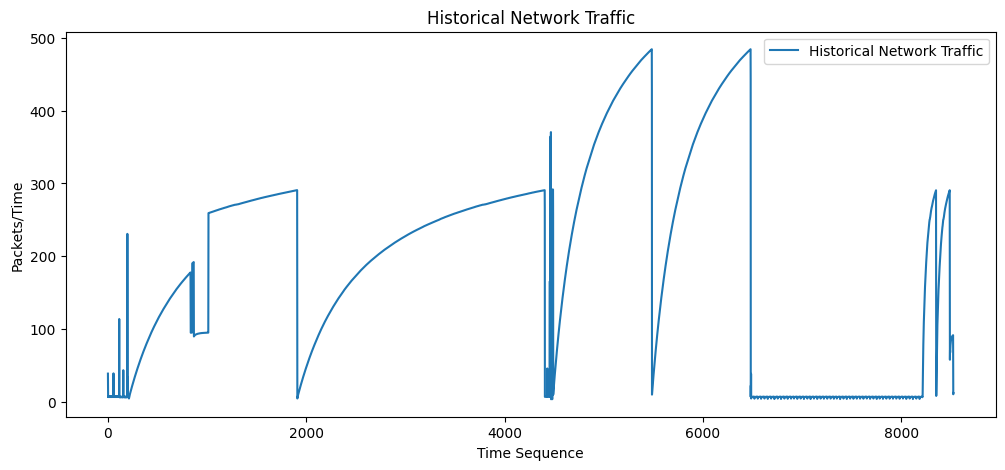


Training Observations: 8426
Testing Observations: 100

Forecast Evaluation
-------------------
MAE : 78.51593750962199
RMSE: 107.0310392795391

DDoS Detection Threshold:
451.91549999999995

Potential Abnormal/DDoS Observations:
0


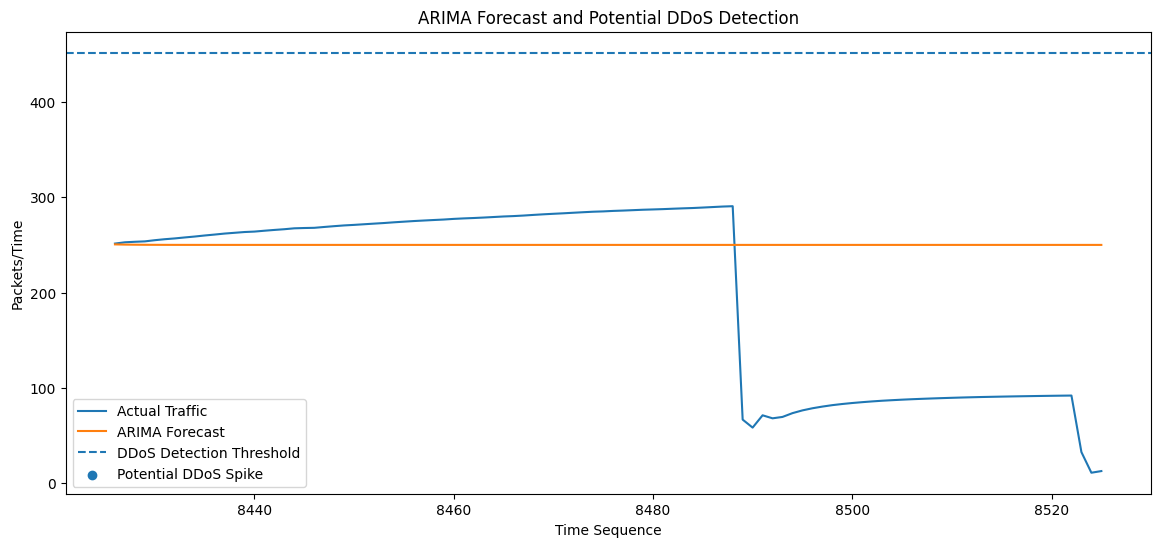


Forecast Results:
    Actual Traffic  Forecasted Traffic  Potential DDoS
0          251.442          250.588457           False
1          252.789          250.359657           False
2          253.319          250.258299           False
3          253.749          250.167077           False
4          254.991          250.126877           False
5          256.025          250.090505           False
6          256.852          250.074562           False
7          257.872          250.060060           False
8          258.832          250.053737           False
9          259.930          250.047955           False
10         260.908          250.045448           False
11         261.951          250.043142           False
12         262.760          250.042148           False
13         263.571          250.041228           False
14         264.036          250.040834           False
15         264.939          250.040468           False
16         265.770          250.040311        

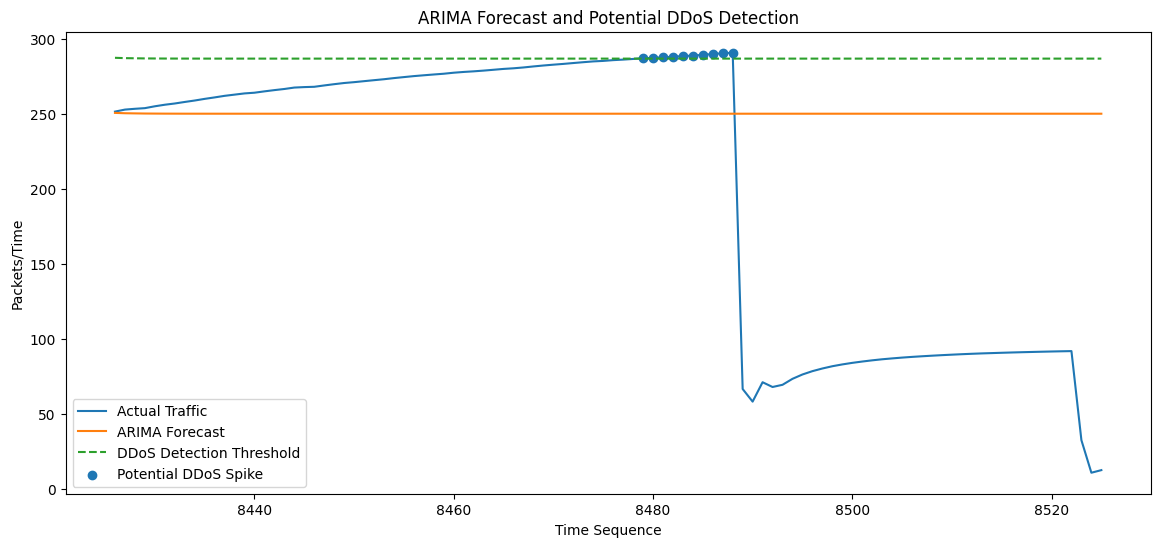


Forecast Results:
    Actual Traffic  Forecasted Traffic  DDoS Threshold  Potential DDoS
0          251.442          250.588457      287.313948           False
1          252.789          250.359657      287.085148           False
2          253.319          250.258299      286.983790           False
3          253.749          250.167077      286.892568           False
4          254.991          250.126877      286.852368           False
5          256.025          250.090505      286.815996           False
6          256.852          250.074562      286.800053           False
7          257.872          250.060060      286.785551           False
8          258.832          250.053737      286.779229           False
9          259.930          250.047955      286.773446           False
10         260.908          250.045448      286.770939           False
11         261.951          250.043142      286.768633           False
12         262.760          250.042148      286.767639    

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

data = pd.read_csv("DDoS_dataset.csv")

print("First Five Records:")
print(data.head())

print("\nDataset Columns:")
print(data.columns)

print("\nDataset Shape:")
print(data.shape)

traffic = pd.to_numeric(
    data["Packets/Time"],
    errors="coerce"
)

traffic = traffic.replace(
    [float("inf"), float("-inf")],
    pd.NA
)

traffic = traffic.dropna().astype(float)


traffic = traffic.groupby(
    traffic.index // 100
).mean()

traffic.index = range(len(traffic))

print("\nNumber of Time-Series Observations:")
print(len(traffic))

print("\nFirst Five Time-Series Values:")
print(traffic.head())

plt.figure(figsize=(12, 5))

plt.plot(
    traffic,
    label="Historical Network Traffic"
)

plt.title("Historical Network Traffic")
plt.xlabel("Time Sequence")
plt.ylabel("Packets/Time")
plt.legend()

plt.show()

forecast_steps = 100

train = traffic.iloc[:-forecast_steps]
test = traffic.iloc[-forecast_steps:]


print("\nTraining Observations:", len(train))
print("Testing Observations:", len(test))


model = ARIMA(
    train,
    order=(2, 1, 2)
)

model_fit = model.fit()


forecast_result = model_fit.get_forecast(
    steps=forecast_steps
)

forecast = forecast_result.predicted_mean


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("\nForecast Evaluation")
print("-------------------")
print("MAE :", mae)
print("RMSE:", rmse)


threshold_value = train.quantile(0.95)

print("\nDDoS Detection Threshold:")
print(threshold_value)


potential_ddos = test > threshold_value

print("\nPotential Abnormal/DDoS Observations:")
print(potential_ddos.sum())


plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test,
    label="Actual Traffic"
)

plt.plot(
    test.index,
    forecast,
    label="ARIMA Forecast"
)

plt.axhline(
    y=threshold_value,
    linestyle="--",
    label="DDoS Detection Threshold"
)

plt.scatter(
    test.index[potential_ddos],
    test[potential_ddos],
    label="Potential DDoS Spike"
)

plt.title(
    "ARIMA Forecast and Potential DDoS Detection"
)

plt.xlabel("Time Sequence")
plt.ylabel("Packets/Time")

plt.legend()

plt.show()


results = pd.DataFrame({
    "Actual Traffic": test.values,
    "Forecasted Traffic": forecast.values,
    "Potential DDoS": potential_ddos.values
})

print("\nForecast Results:")
print(results.head(20))


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("\nForecast Evaluation")
print("-------------------")
print("MAE :", mae)
print("RMSE:", rmse)

residuals = train - model_fit.fittedvalues

residual_std = residuals.dropna().std()

threshold = forecast + (3 * residual_std)

potential_ddos = test > threshold

print("\nPotential Abnormal/DDoS Observations:")
print(potential_ddos.sum())


plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    test,
    label="Actual Traffic"
)

plt.plot(
    test.index,
    forecast,
    label="ARIMA Forecast"
)

plt.plot(
    test.index,
    threshold,
    linestyle="--",
    label="DDoS Detection Threshold"
)


plt.scatter(
    test.index[potential_ddos],
    test[potential_ddos],
    label="Potential DDoS Spike"
)

plt.title(
    "ARIMA Forecast and Potential DDoS Detection"
)

plt.xlabel("Time Sequence")
plt.ylabel("Packets/Time")

plt.legend()

plt.show()

results = pd.DataFrame({
    "Actual Traffic": test.values,
    "Forecasted Traffic": forecast.values,
    "DDoS Threshold": threshold.values,
    "Potential DDoS": potential_ddos.values
})

print("\nForecast Results:")
print(results.head(20))

# New Section